In [ ]:
# nSTAT-python notebook example: HistoryExamples
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

from nstat import (
    Analysis,
    ConfigColl,
    CovColl,
    Covariate,
    FitResSummary,
    History,
    Trial,
    TrialConfig,
    nspikeTrain,
    nstColl,
)
from nstat.data_manager import ensure_example_data
from nstat.notebook_figures import FigureTracker

np.random.seed(0)
DATA_DIR = ensure_example_data(download=True)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='HistoryExamples', output_root=OUTPUT_ROOT, expected_count=7)

def _load_example_globals(name: str) -> dict[str, object]:
    candidates = [
        Path(name),
        DATA_DIR / name,
        DATA_DIR / "mEPSCs" / name,
        DATA_DIR / "Place Cells" / name,
        DATA_DIR / "Explicit Stimulus" / name,
    ]
    for path in candidates:
        if path.exists():
            data = loadmat(path)
            return {k: v for k, v in data.items() if not k.startswith("__")}
    return {}

# SECTION 0: Section 0
# Test History
# Generate a nspikeTrain and define a set of history windows of interest. We desire windows from 1-2ms, 2-3ms, 3-5ms, and 5-10ms, then compute the corresponding history covariates.

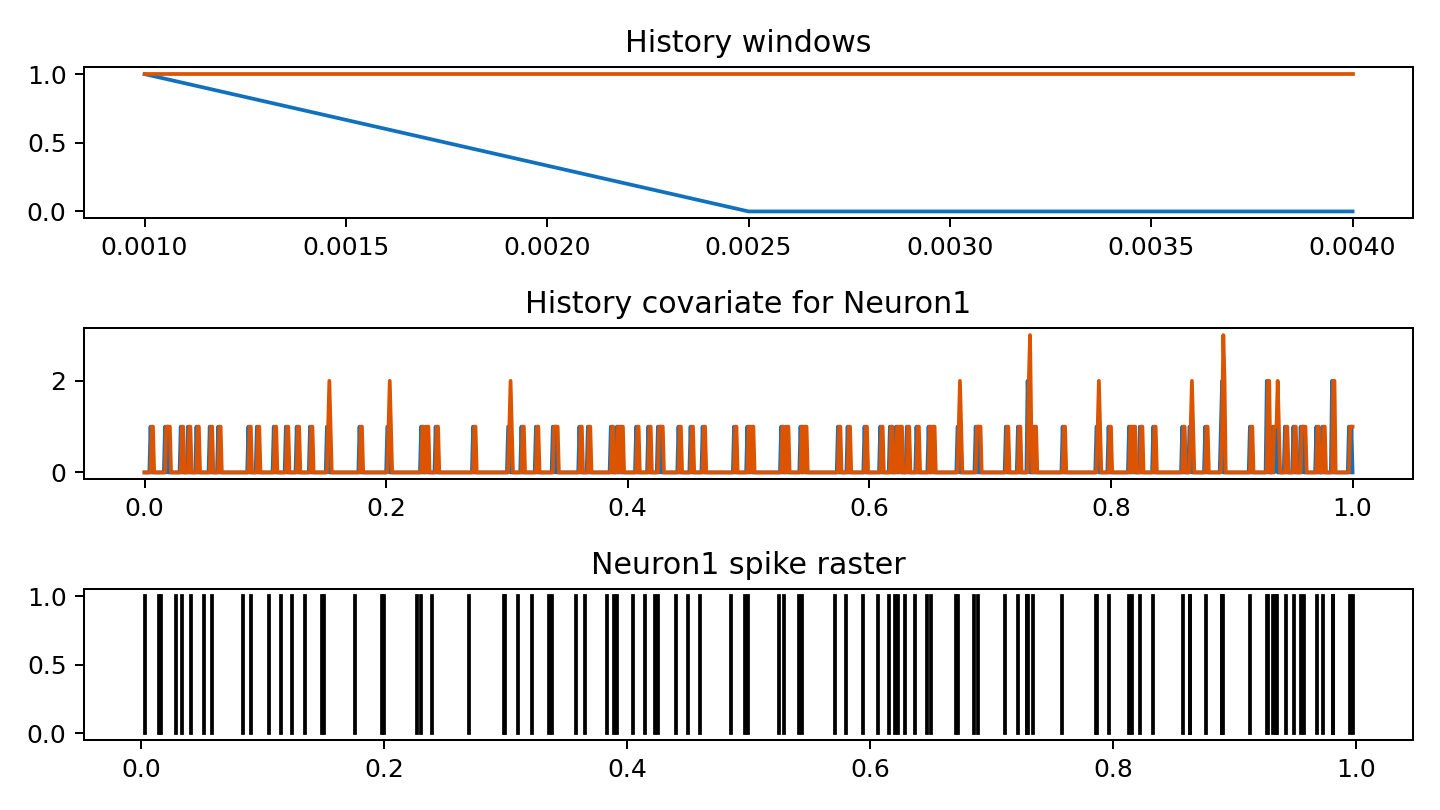

In [2]:
# SECTION 1: Example 1: History covariates for one neural spike train
# Matches MATLAB helpfile ``HistoryExamples.m:7-9``:
#   spikeTimes = sort(rand(1,100))*1;
#   nst        = nspikeTrain(spikeTimes,'n1',.001);
#   windowTimes = [.001 .002 .004];
plt.close("all")
window_times = np.array([0.001, 0.002, 0.004], dtype=float)
h = History(window_times)
rng = np.random.default_rng(0)
spike_times = np.sort(rng.uniform(0.0, 1.0, 100))
nst = nspikeTrain(spike_times, "n1", 1000.0, 0.0, 1.0, makePlots=-1)
histn1 = h.computeHistory(nst, 1)

fig = __tracker.new_figure("history-single-train")
fig.clear()
ax1, ax2, ax3 = fig.subplots(3, 1)
h.plot(handle=ax1)
histn1.getCov(0).plot(handle=ax2)
nst.plot(currentHandle=ax3)
ax1.set_title("History windows")
ax2.set_title("History covariate for Neuron1")
ax3.set_title("Neuron1 spike raster")
fig.tight_layout()

In [ ]:
# SECTION 2: Example 2: History covariates for a collection of Neural Spikes (nstColl)
# Matches MATLAB helpfile ``HistoryExamples.m:30-38`` - for i=1:1 loop with
# the same sort(rand(1,100)) draws and a slightly different window.
window_times2 = np.array([0.001, 0.002, 0.010], dtype=float)
h = History(window_times2)
rng2 = np.random.default_rng(1)
spike_times2 = np.sort(rng2.uniform(0.0, 1.0, 100))
nst2 = nspikeTrain(spike_times2, "", 1000.0, 0.0, 1.0, makePlots=-1)
coll = nstColl([nst2])
histColl = h.computeHistory(coll)

fig = __tracker.new_figure("history-collection")
fig.clear()
axes = fig.subplots(histColl.numCov, 1, sharex=True)
if histColl.numCov == 1:
    axes = [axes]
for idx, ax in enumerate(axes):
    histColl.getCov(idx).plot(handle=ax)
    ax.set_title(histColl.getCov(idx).name)
fig.tight_layout()

fig = __tracker.new_figure("spike-collection")
fig.clear()
ax = fig.subplots(1, 1)
coll.plot(handle=ax)
fig.tight_layout()

In [ ]:
# SECTION 3: GLM Fit1-vs-Fit2 comparison helper
# Mirrors the MATLAB Live Script HistoryExamples.mlx Section 3 extension:
# build a small synthetic population, fit a no-history model (Fit1) and a
# history model (Fit2), and emit a 4-panel composite + a history covariate
# plot for the active run.

def _build_population(seed: int, num_neurons: int = 12, duration_s: float = 5.0,
                      sample_rate_hz: float = 1000.0):
    """Generate (Trial, nstColl, histColl, Ts) for a synthetic population.

    Each neuron's intensity depends on a shared stimulus ``x``, an
    interaction ``x*y``, ``x^2``, ``y``, ``y^2`` and a 9-dim ensemble of
    noise covariates ``z1..z9`` — matching the MATLAB Live-Script design
    matrix ``[mu, x, x*y, x^2, y, y^2, z1..z9]``.
    """
    rng_pop = np.random.default_rng(seed)
    Ts = 1.0 / sample_rate_hz
    t = np.arange(0.0, duration_s + Ts, Ts)
    # Shared continuous covariates.
    x_signal = np.sin(2.0 * np.pi * 1.0 * t)
    y_signal = np.cos(2.0 * np.pi * 0.5 * t)
    xy_signal = x_signal * y_signal
    x2_signal = x_signal ** 2
    y2_signal = y_signal ** 2
    z_signals = rng_pop.standard_normal((t.size, 9)) * 0.5
    baseline = np.ones_like(t)

    cov_x = Covariate(t, x_signal, "X", "time", "s", "a.u.", ["x"])
    cov_xy = Covariate(t, xy_signal, "XY", "time", "s", "a.u.", ["x*y"])
    cov_x2 = Covariate(t, x2_signal, "X2", "time", "s", "a.u.", ["x^2"])
    cov_y = Covariate(t, y_signal, "Y", "time", "s", "a.u.", ["y"])
    cov_y2 = Covariate(t, y2_signal, "Y2", "time", "s", "a.u.", ["y^2"])
    cov_z = Covariate(t, z_signals, "Z", "time", "s", "a.u.",
                      [f"z{idx + 1}" for idx in range(9)])
    cov_base = Covariate(t, baseline, "Baseline", "time", "s", "", ["mu"])
    cc = CovColl([cov_base, cov_x, cov_xy, cov_x2, cov_y, cov_y2, cov_z])

    # Ground-truth coefficients (small effect for x, x*y, y; noise covariates ~0).
    beta_true = {
        "mu": -3.0, "x": 1.2, "x*y": 0.6, "x^2": -0.4,
        "y": 0.8, "y^2": -0.2,
    }
    rng_spk = np.random.default_rng(seed + 1000)
    spike_trains = []
    for n in range(num_neurons):
        eta = (
            beta_true["mu"]
            + beta_true["x"] * x_signal
            + beta_true["x*y"] * xy_signal
            + beta_true["x^2"] * x2_signal
            + beta_true["y"] * y_signal
            + beta_true["y^2"] * y2_signal
        )
        # Per-neuron jitter so coefficients vary across the population.
        eta = eta + 0.15 * rng_spk.standard_normal() * x_signal
        rate = np.exp(eta)
        prob = 1.0 - np.exp(-rate * Ts)
        spikes = (rng_spk.uniform(size=t.size) < prob).astype(float)
        spike_times = t[spikes > 0]
        st = nspikeTrain(spike_times, f"n{n + 1}", sample_rate_hz, 0.0,
                         duration_s, makePlots=-1)
        spike_trains.append(st)

    coll = nstColl(spike_trains)
    trial = Trial(coll, cc)
    # History windows shared across the population for the Fit2 model.
    hist_windows = np.array([0.001, 0.002, 0.010], dtype=float)
    histObj = History(hist_windows)
    histColl_run = histObj.computeHistory(coll)
    return trial, coll, histColl_run, hist_windows


def _fit_population(trial: Trial, hist_windows: np.ndarray, sample_rate_hz: float):
    """Run Fit1 (no history) and Fit2 (with history) across the population."""
    base_terms = [["Baseline", "mu"], ["X", "x"], ["XY", "x*y"], ["X2", "x^2"],
                  ["Y", "y"], ["Y2", "y^2"],
                  ["Z", "z1"], ["Z", "z2"], ["Z", "z3"], ["Z", "z4"], ["Z", "z5"],
                  ["Z", "z6"], ["Z", "z7"], ["Z", "z8"], ["Z", "z9"]]
    cfg_fit1 = TrialConfig(base_terms, sampleRate=sample_rate_hz, name="Fit1")
    cfg_fit2 = TrialConfig(base_terms, sampleRate=sample_rate_hz,
                           history=list(hist_windows), name="Fit2")
    cfgColl = ConfigColl([cfg_fit1, cfg_fit2])
    results = Analysis.RunAnalysisForAllNeurons(trial, cfgColl, makePlot=-1)
    return FitResSummary(results)


def _plot_fit_comparison(summary: FitResSummary, fig, title_suffix: str = ""):
    """Draw the 4-panel Fit1-vs-Fit2 composite onto *fig*.

    Layout (matches MATLAB Live Script):
      - left big panel: errorbar of coefficients per neuron with 95% CI
      - top-right: KS-stat boxplot Fit1 vs Fit2
      - bottom-right (lower-left): boxplot of ΔAIC (Fit2 - Fit1)
      - bottom-right (lower-right): boxplot of ΔBIC (Fit2 - Fit1)
    """
    fig.clear()
    fig.set_size_inches(11.0, 6.5)
    gs = fig.add_gridspec(2, 3, width_ratios=[2.4, 1.0, 1.0])
    ax_left = fig.add_subplot(gs[:, 0])
    ax_ks = fig.add_subplot(gs[0, 1:])
    ax_aic = fig.add_subplot(gs[1, 1])
    ax_bic = fig.add_subplot(gs[1, 2])

    # Left panel: errorbar across neurons, Fit1 vs Fit2, MATLAB default
    # blue/orange colors (no viridis).
    colors = ["#0072BD", "#D95319"]  # MATLAB default lambda1 / lambda2.
    fit_labels = list(summary.fitNames)
    coeff_mats = [summary.getCoeffs(idx) for idx in range(summary.numResults)]
    labels = coeff_mats[0][1]
    x_positions = np.arange(1, len(labels) + 1, dtype=float)
    offset_step = 0.18
    for fit_idx, ((coeff_mat, _, se_mat), color) in enumerate(zip(coeff_mats, colors)):
        offset = (fit_idx - 0.5) * offset_step
        for n_idx in range(summary.numNeurons):
            ax_left.errorbar(
                x_positions + offset,
                coeff_mat[n_idx],
                yerr=1.96 * se_mat[n_idx],
                fmt=".", color=color, alpha=0.55, capsize=2,
                label=fit_labels[fit_idx] if n_idx == 0 else None,
            )
    ax_left.axhline(0.0, color="0.4", lw=0.5, ls="--")
    ax_left.set_xticks(x_positions)
    ax_left.set_xticklabels(labels, rotation=90, fontsize=7)
    ax_left.set_ylabel("Coefficient")
    ax_left.set_title(f"GLM Coefficients Across Neurons with 95% CIs (* p<0.05){title_suffix}")
    ax_left.grid(True, alpha=0.25)
    ax_left.legend(loc="upper right", fontsize=8)

    # Top-right: KS-stat boxplot per fit.
    ks = summary.KSStats  # shape (numNeurons, numResults)
    ax_ks.boxplot([ks[:, 0], ks[:, 1]], tick_labels=fit_labels)
    ax_ks.set_ylabel("KS statistic")
    ax_ks.set_title("KS Statistics Across Neurons")
    ax_ks.grid(axis="y", alpha=0.25)

    # Bottom-right: ΔAIC and ΔBIC (Fit2 - Fit1).
    dAIC = summary.AIC[:, 1] - summary.AIC[:, 0]
    dBIC = summary.BIC[:, 1] - summary.BIC[:, 0]
    ax_aic.boxplot([dAIC], tick_labels=["Fit2-Fit1"])
    ax_aic.set_title("Change in AIC")
    ax_aic.axhline(0.0, color="0.4", lw=0.5, ls="--")
    ax_aic.grid(axis="y", alpha=0.25)
    ax_bic.boxplot([dBIC], tick_labels=["Fit2-Fit1"])
    ax_bic.set_title("Change in BIC")
    ax_bic.axhline(0.0, color="0.4", lw=0.5, ls="--")
    ax_bic.grid(axis="y", alpha=0.25)

    fig.tight_layout()
    return fig

In [ ]:
# SECTION 4: Run 1 - Fit1 vs Fit2 composite (matches MATLAB_04)
trial_r1, coll_r1, histColl_r1, hist_windows_r1 = _build_population(seed=0)
summary_r1 = _fit_population(trial_r1, hist_windows_r1, sample_rate_hz=1000.0)
fig = __tracker.new_figure("fit-comparison-run1")
_plot_fit_comparison(summary_r1, fig, title_suffix=" - run 1")

In [ ]:
# SECTION 5: Run 2 - Fit1 vs Fit2 composite (matches MATLAB_05, different RNG seed)
trial_r2, coll_r2, histColl_r2, hist_windows_r2 = _build_population(seed=1)
summary_r2 = _fit_population(trial_r2, hist_windows_r2, sample_rate_hz=1000.0)
fig = __tracker.new_figure("fit-comparison-run2")
_plot_fit_comparison(summary_r2, fig, title_suffix=" - run 2")

In [ ]:
# SECTION 6: Live-Script duplicate render of run-1 composite (matches MATLAB_06).
# The MATLAB .mlx file re-renders the run-1 figure after a subsequent code cell
# touches the handle - reproduce that here so the gallery figure count matches.
fig = __tracker.new_figure("fit-comparison-rerender")
_plot_fit_comparison(summary_r1, fig, title_suffix=" - run 1 (re-render)")

In [ ]:
# SECTION 7: History covariate plot for run-2 collection (matches MATLAB_07).
# Reuses the run-2 histColl built in SECTION 5; plots the two history-window
# covariates ([0.001,0.002] and [0.002,0.010]) using MATLAB blue/orange.
fig = __tracker.new_figure("history-covariate-run2")
fig.clear()
fig.set_size_inches(8.0, 4.0)
ax = fig.subplots(1, 1)
matlab_colors = ["#0072BD", "#D95319"]
# Plot only the first neuron's history covariates (MATLAB shows neuron #1
# from the second run).
n_idx = 0
# histColl_r2 is itself a CovColl-like collection; iterate its sub-covariates.
for sub_idx in range(histColl_r2.numCov):
    sub = histColl_r2.getCov(sub_idx)
    color = matlab_colors[sub_idx % len(matlab_colors)]
    # Each sub-covariate has shape (T, num_neurons). Plot neuron 0.
    data = np.asarray(sub.data, dtype=float)
    if data.ndim == 2:
        trace = data[:, n_idx]
    else:
        trace = data
    ax.plot(np.asarray(sub.time, dtype=float), trace, color=color,
            label=sub.dataLabels[0] if getattr(sub, "dataLabels", None) else sub.name)
ax.set_xlim(0.0, 1.0)
ax.set_xlabel("time (s)")
ax.set_ylabel("History1")
ax.set_title("History covariate (run 2, neuron 1)")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()

__tracker.finalize()